In [1]:
import sys, os
import matplotlib
import mne

print(sys.executable)
print(matplotlib.get_backend())
print(mne.__version__)
print("DISPLAY:", os.environ.get('DISPLAY', 'not set'))
print("interactive:", matplotlib.is_interactive())

import IPython
print("IPython:", IPython.get_ipython())

/home/alouis/mne_env/bin/python
module://matplotlib_inline.backend_inline
1.12.1
DISPLAY: not set
interactive: False
IPython: <ipykernel.zmqshell.ZMQInteractiveShell object at 0x14dcc77f7490>


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from mne_bids import BIDSPath, read_raw_bids

In [3]:
bids_path = BIDSPath(
    subject='01',
    task='sleep',
    datatype='eeg',
    root='/home/alouis/scratch/dream_bids/'
)
raw = read_raw_bids(bids_path, verbose=False)
raw.pick('eeg')
raw.load_data(verbose=False)

/tmp/ipykernel_3946948/3934084418.py:7: RuntimeWarning: There are channels without locations (n/a) that are not marked as bad: ['EOG_L', 'EOG_R', 'EMG_chin', 'misc1', 'misc2', 'misc3']
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_3946948/3934084418.py:7: RuntimeWarning: Not setting positions of 6 emg/eog/misc channels found in montage:
['EOG_L', 'EOG_R', 'EMG_chin', 'misc1', 'misc2', 'misc3']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = read_raw_bids(bids_path, verbose=False)


<RawBrainVision | sub-01_task-sleep_eeg.eeg, 19 x 28409780 (28409.8 s), ~4.02 GiB, data loaded>

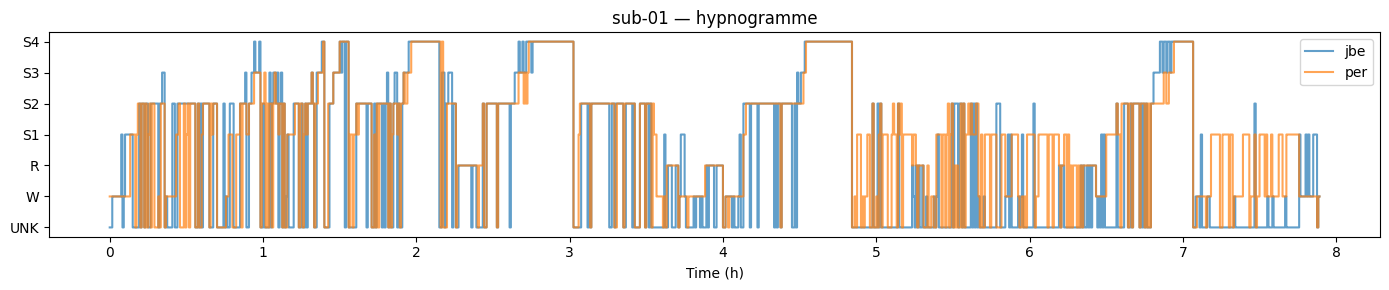

In [4]:
# Hypnogramme jbe vs per
stage_map = {'W': 0, 'R': 1, 'S1': 2, 'S2': 3, 'S3': 4, 'S4': 5, 'UNKNOWN_m1': -1, 'UNKNOWN_m2': -1}

fig, ax = plt.subplots(figsize=(14, 3))
for scorer in ['jbe', 'per']:
    times, stages = [], []
    for ann in raw.annotations:
        if ann['description'].startswith(scorer + '/'):
            label = ann['description'].split('Sleep stage ')[-1] if 'Sleep stage' in ann['description'] else ann['description'].split('/')[-1]
            times.append(ann['onset'])
            stages.append(stage_map.get(label, -1))
    ax.step(np.array(times) / 3600, stages, label=scorer, where='post', alpha=0.7)

ax.set_yticks([-1, 0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['UNK', 'W', 'R', 'S1', 'S2', 'S3', 'S4'])
ax.set_xlabel('Time (h)')
ax.set_title('sub-01 — hypnogramme')
ax.legend()
plt.tight_layout()
plt.show()

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


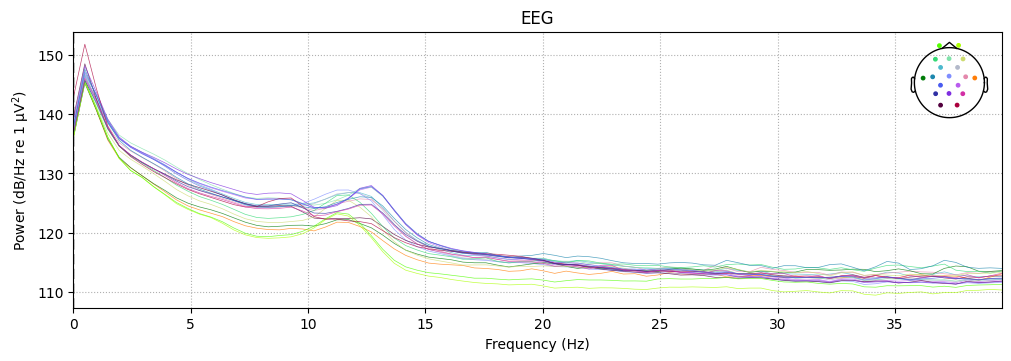

In [5]:
# PSD globale
fig = raw.compute_psd(fmax=40).plot(show=False)
plt.show()

In [10]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

In [15]:
print(raw.info['chs'][0]['unit'])  # 107 = µV, 112 = V
print(raw.get_data()[:, 0].max())

107 (FIFF_UNIT_V)
144.19999999999987


In [16]:
print(raw.info['chs'][0]['cal'])
print(raw.info['chs'][0]['range'])

0.1
1e-06


In [18]:
def plot_eeg_segment(raw, start_s, duration_s=30, n_ch=19, scale=50e-6):
    start = int(start_s * raw.info['sfreq'])
    stop = int((start_s + duration_s) * raw.info['sfreq'])
    data, times = raw[:n_ch, start:stop]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, ch in enumerate(range(n_ch)):
        ax.plot(times, data[ch] / scale + i, 'k', lw=0.5)
    ax.set_yticks(range(n_ch))
    ax.set_yticklabels(raw.ch_names[:n_ch])
    ax.set_xlabel('Time (s)')
    return fig

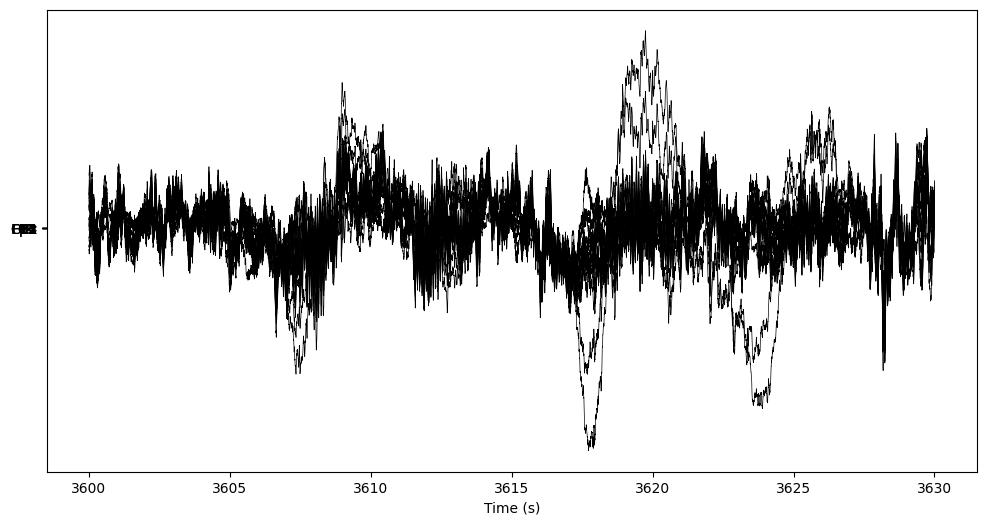

In [19]:
fig = plot_eeg_segment(raw, start_s=3600, scale=100e-6)

In [20]:
std = raw.get_data()[:19, :1000].std(axis=1).mean()
print(std)

17.820578633647653


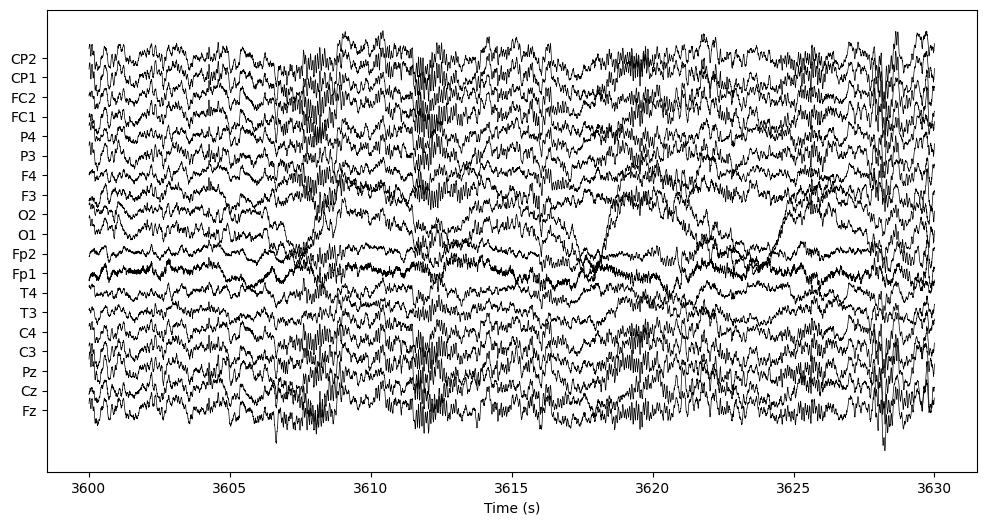

In [21]:
fig = plot_eeg_segment(raw, start_s=3600, scale=50)  # pas de 1e-6

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 133 samples (0.133 s)



/tmp/ipykernel_3946948/1080602521.py:3: RuntimeWarning: The measurement information indicates a low-pass frequency of 100.0 Hz. The decim=4 parameter will result in a sampling frequency of 250.0 Hz, which can cause aliasing artifacts.
  fig = raw.plot(duration=30, start=3600, n_channels=19, show=False,


KeyboardInterrupt: 

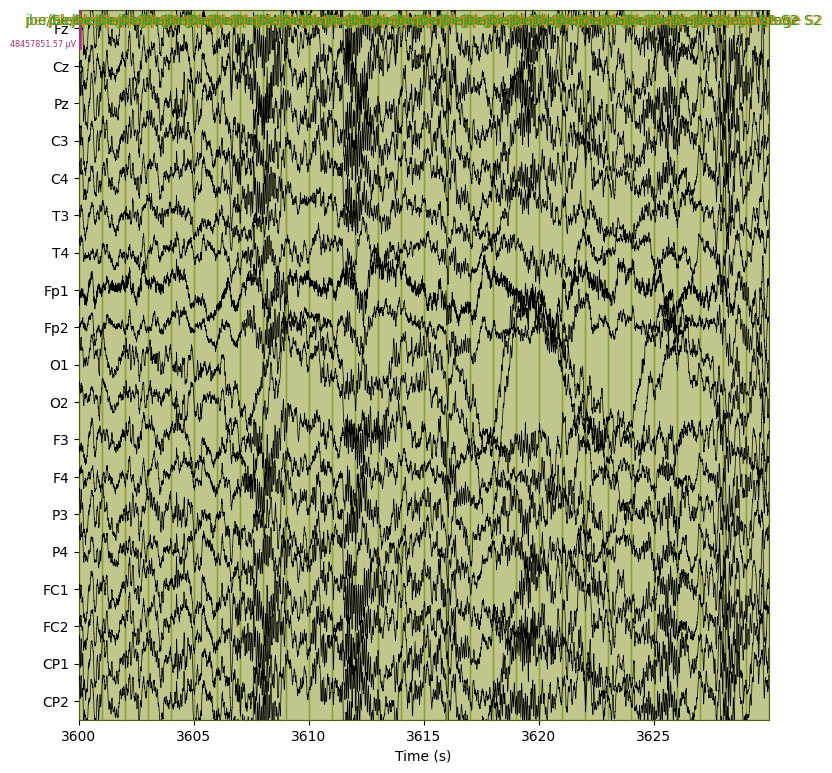

In [14]:
# # Plot 30s de signal brut
# raw.filter(None, 100.)
# fig = raw.plot(duration=30, start=3600, n_channels=19, show=False,
#                scalings='auto', decim=4,
#                show_scrollbars=False)
# plt.show()

In [23]:
print(raw.get_data()[:19, :1000].std(axis=1).mean() * 1e6)  # converti en µV

17820578.633647654


In [ ]:
print(raw.times[-1])

In [ ]:
fig = raw.compute_psd(fmax=raw.info['sfreq']/2).plot(show=False)

In [ ]:
fig = plot_eeg_segment(raw, start_s=3600)
fig.savefig('seg_1h.png', dpi=72, bbox_inches='tight')
plt.close(fig)